<a href="https://colab.research.google.com/github/wndydsr/Praktikum-Pengolahan-Citra/blob/main/Jobsheet4_SegmentasiGambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JOBSHEET 4 - SEGMENTASI GAMBAR

Nama: Windy Destiana Sari  
NIM: 3.34.23.3.25

Kelas: IK-3D  
Mata Kuliah: Pengolahan Citra

###**Segmentasi Menggunakan Thresholding Global dan Otsu**


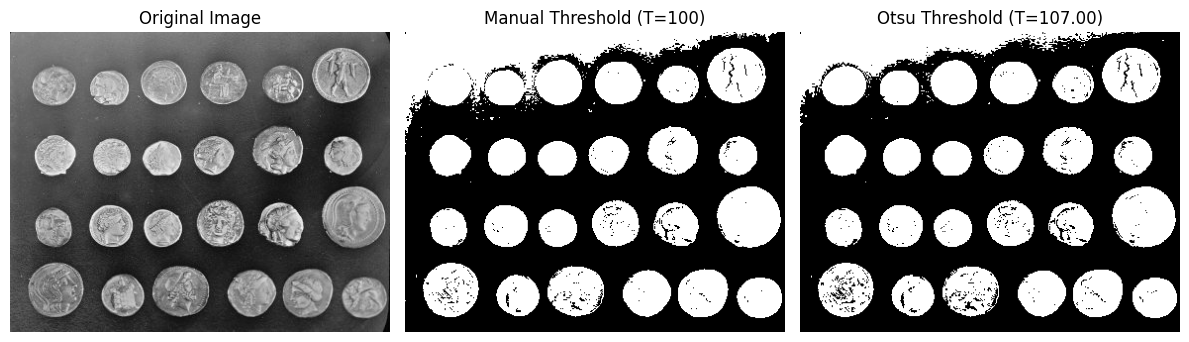

Nilai threshold Otsu yang ditemukan: 107


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters

# Memuat citra (grayscale)
image_coins = data.coins()

# Thresholding manual
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# Visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

###**Segmentasi Menggunakan Region Growing (Contoh Sederhana)**


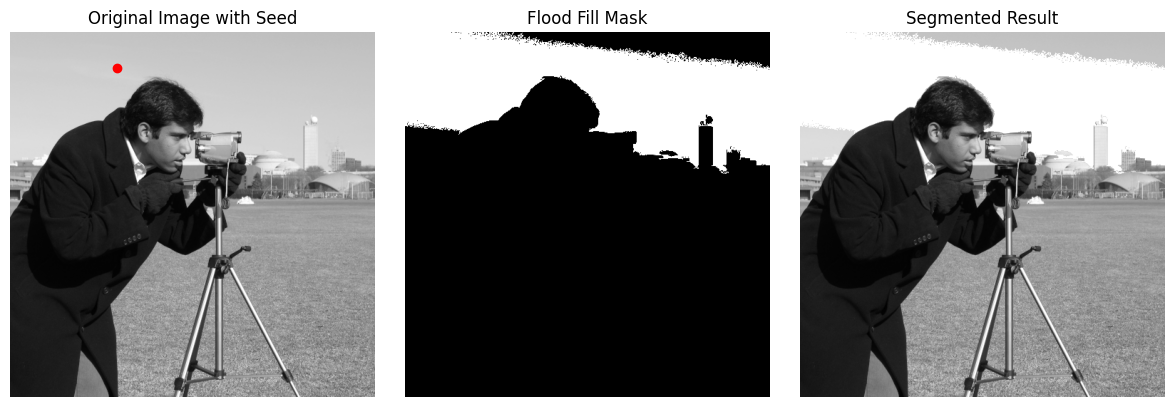

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# Memuat citra grayscale
image_camera = data.camera()

# Seed point (titik awal region growing)
seed_point = (50, 150)

# Flood fill (region growing sederhana)
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# Hasil segmentasi
segmented_image = image_camera.copy()
segmented_image[flood_mask] = 255

# Visualisasi
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Fill Mask')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Result')
ax[2].axis('off')

plt.tight_layout()
plt.show()

###**Segmentasi Citra Berwarna Menggunakan K-Means Clustering**

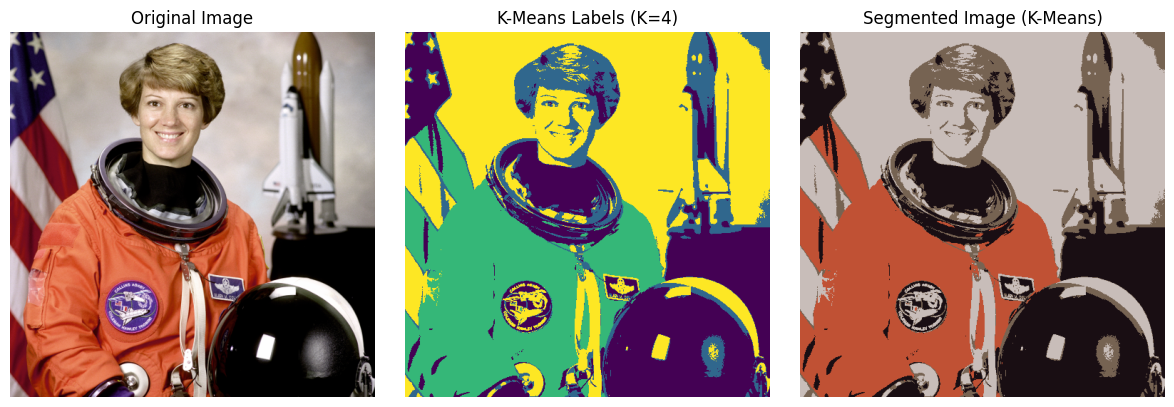

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# Memuat citra RGB
image = data.astronaut()
image_float = image.astype(float) / 255.0

# Konversi ke ruang warna Lab
image_lab = rgb2lab(image_float)
rows, cols, dims = image_lab.shape
pixels = image_lab.reshape(rows * cols, dims)

# K-Means clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    labels = kmeans.fit_predict(pixels)

# Bentuk ulang label ke citra
segmented_labels = labels.reshape(rows, cols)

# Rekonstruksi citra berdasarkan cluster
segmented_lab = np.zeros_like(image_lab)
centers = kmeans.cluster_centers_

for k in range(n_clusters):
    mask = segmented_labels == k
    segmented_lab[mask] = centers[k]

# Konversi ke RGB
segmented_rgb = lab2rgb(segmented_lab)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(segmented_labels, cmap="viridis")
axes[1].set_title(f"K-Means Labels (K={n_clusters})")
axes[1].axis("off")

axes[2].imshow(segmented_rgb)
axes[2].set_title("Segmented Image (K-Means)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

###**Segmentasi Berbasis Tepi Menggunakan Watershed**


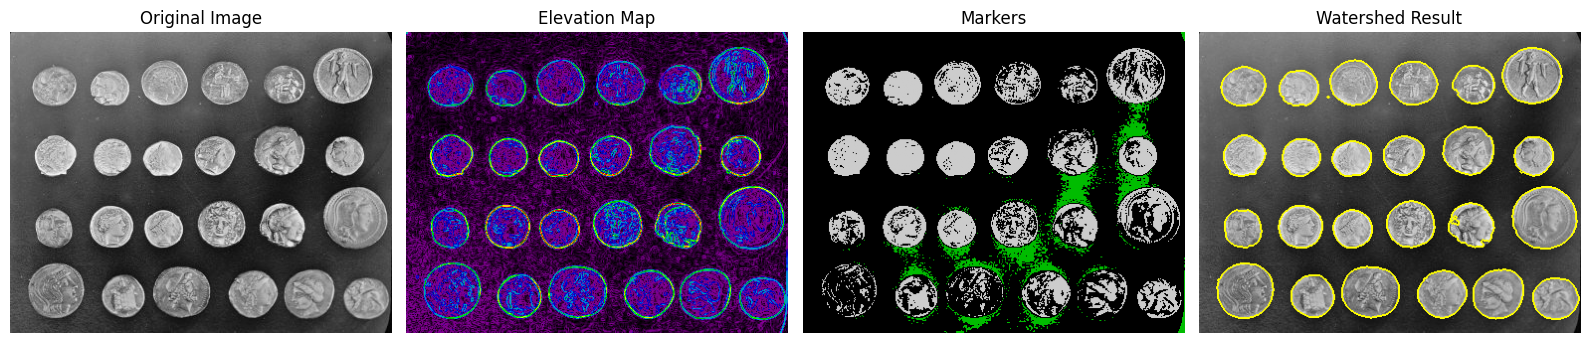

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation

# Memuat citra grayscale
image = data.coins()

# Elevation map (gradien)
elevation_map = filters.sobel(image)

# Marker sederhana
markers = np.zeros_like(image)
markers[image < 30] = 1   # background
markers[image > 150] = 2  # objek

# Watershed segmentation
labels = segmentation.watershed(elevation_map, markers)

# Visualisasi boundary
segmented = segmentation.mark_boundaries(image, labels)

# Plot hasil
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(elevation_map, cmap="nipy_spectral")
axes[1].set_title("Elevation Map")
axes[1].axis("off")

axes[2].imshow(markers, cmap="nipy_spectral")
axes[2].set_title("Markers")
axes[2].axis("off")

axes[3].imshow(segmented)
axes[3].set_title("Watershed Result")
axes[3].axis("off")

plt.tight_layout()
plt.show()

###**Perbandingan Visual Hasil Segmentasi**

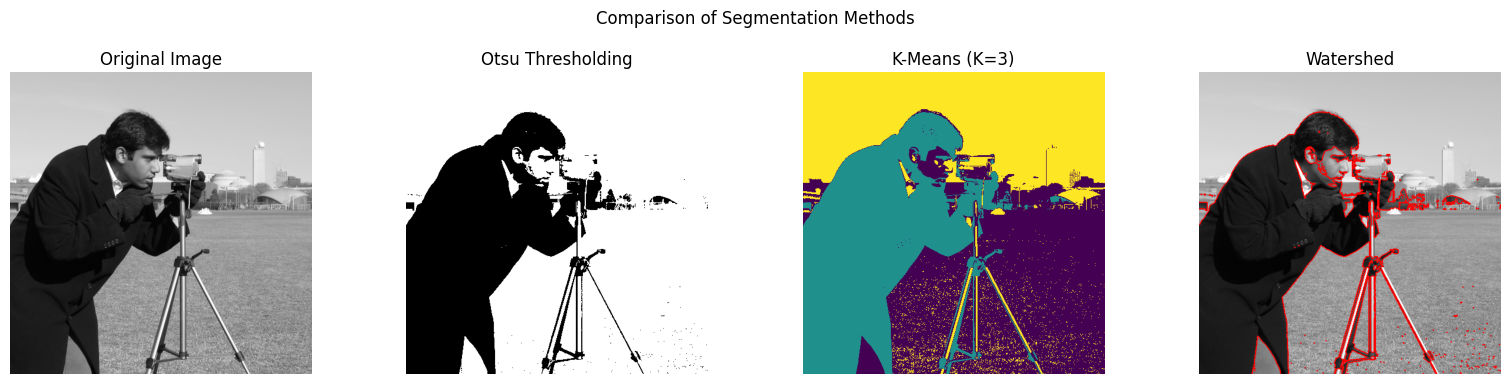

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan (misal: camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Lakukan beberapa metode segmentasi

# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

segmented_watershed_colored = segmentation.mark_boundaries(
    image_float,
    segmentation_watershed,
    color=(1, 0, 0)
)

ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##**Penugasan Eksperimen Thresholding**

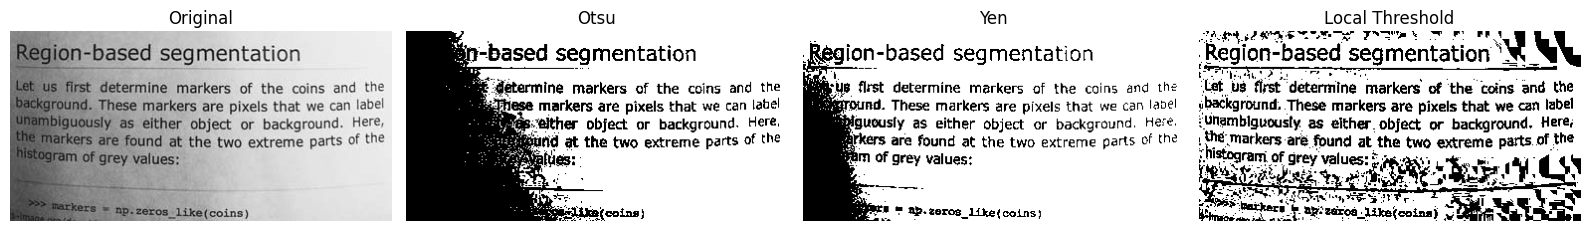

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte

image = data.page()

# Otsu
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# Yen
thresh_yen = filters.threshold_yen(image)
binary_yen = image > thresh_yen

# Local threshold
local_thresh = filters.threshold_local(image, block_size=35)
binary_local = image > local_thresh

# Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(binary_otsu, cmap="gray")
axes[1].set_title("Otsu")
axes[1].axis("off")

axes[2].imshow(binary_yen, cmap="gray")
axes[2].set_title("Yen")
axes[2].axis("off")

axes[3].imshow(binary_local, cmap="gray")
axes[3].set_title("Local Threshold")
axes[3].axis("off")

plt.tight_layout()
plt.show()

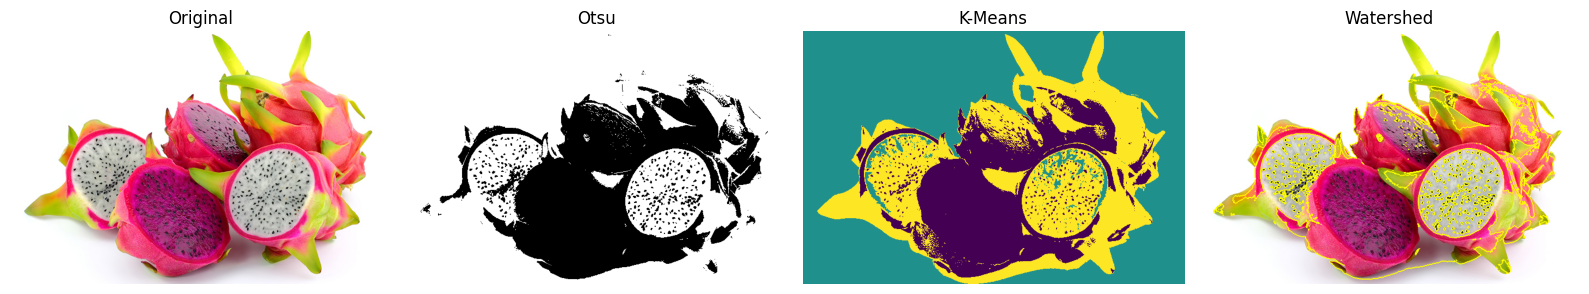

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, segmentation, color, img_as_float
from sklearn.cluster import KMeans
import warnings

# Load gambar dari file upload
image = io.imread('/content/buahnaga.jpg')
image = img_as_float(image)

# Grayscale
image_gray = color.rgb2gray(image)

# 1. OTSU
thresh = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh

# 2. K-MEANS
rows, cols, ch = image.shape
pixel_features = image.reshape(rows * cols, ch)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    labels = kmeans.fit_predict(pixel_features)

segmented_kmeans = labels.reshape(rows, cols)


# 3. WATERSHED
elevation_map = filters.sobel(image_gray)

markers = np.zeros(image_gray.shape, dtype=np.intc)
markers[image_gray < thresh] = 1
markers[image_gray > thresh] = 2

watershed = segmentation.watershed(elevation_map, markers)
watershed_colored = segmentation.mark_boundaries(image, watershed)


# TAMPILKAN HASIL

fig, axes = plt.subplots(1, 4, figsize=(16,4))
ax = axes.ravel()

ax[0].imshow(image)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title('K-Means')
ax[2].axis('off')

ax[3].imshow(watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.tight_layout()
plt.savefig('hasil_segmentasi.png', dpi=300)  # simpan gambar
plt.show()